In [7]:
import os
import re
import sys
import logging
import json
import numpy as np
import pandas as pd
import pickle
import xgboost as xgb
import plotly.graph_objects as go
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
import joblib
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap
from sqlalchemy import create_engine
sys.path.append("/dss/work/rirg2545/actionable-hypotension/")



# ----------------------
# Configuration
# ----------------------
OPTIMIZED_MODEL_PATH = "/dss/work/rirg2545/actionable-hypotension/models_given/optimized/xgb_mix.json"
SHAP_RESULTS_DIR = "/dss/work/rirg2545/actionable-hypotension/extended_evaluation_review/shap/results"
LOG_LEVEL = logging.INFO
# ----------------------
# Set up logging
# ----------------------
logging.basicConfig(
level=LOG_LEVEL,
format="%(asctime)s [%(levelname)s] %(message)s",
datefmt="%Y-%m-%d %H:%M:%S")
# -----
# DB connection
DATABASE_URI = "postgresql+psycopg2://rirg2545@localhost:5434/mimic"
engine = create_engine(DATABASE_URI, future=True)

decision_thresholds = {
"mix": 0.0011452179169282317,
"inv_model": 0.0020985996816307306,
"noninv_model": 0.0008126477478072047}

UNCALIBRATED_MODELS_DIR = "/dss/work/rirg2545/actionable-hypotension/models_given/uncalibrated"
inv_model = "/dss/work/rirg2545/actionable-hypotension/models_given/uncalibrated/xgb_inv.json"
non_inv_model = "/dss/work/rirg2545/actionable-hypotension/models_given/uncalibrated/xgb_noninv.json"
CALIBRATED_MODELS_DIR = "/dss/work/rirg2545/actionable-hypotension/extended_evaluation_review/models_calibrated_unbundled"
BASE_MODEL_C = "/dss/work/rirg2545/actionable-hypotension/extended_evaluation_review/models_calibrated_unbundled/xgb_mix_calibrator.pkl"
BASE_MODEL_UC ="/dss/work/rirg2545/actionable-hypotension/models_given/uncalibrated/xgb_mix.json"

In [2]:
def load_and_prepare_data_xgb(table_name):
    
    cache = {} 
    if table_name in cache:
        logging.info(f"🔁 Using cached data for {table_name} ")
        return cache[table_name]

    logging.info(f" Loading train data from ce_approach.{table_name}")


    df = pd.read_sql(f"""
        SELECT * FROM ce_approach.{table_name}
        ORDER BY subject_id, icustay_id, context_start
    """, engine)

    # Vorverarbeitung
    # Label engineering
    df["label"] = df["positive_event"].astype(int)
    id_cols = ["subject_id", "icustay_id", "context_start", "context_end"]
    excluded = {"positive_event", "positive_sample", "split", "label", "treatment_given", "only_2_values"} | set(id_cols)
    
    logging.info(f"Features excluded: {excluded}")

    feature_cols = [c for c in df.columns if c not in excluded]
    train_df = df[df["split"] == "train"]
    val_df = df[df["split"] == "val"]
    test_df = df[df["split"] == "test"]

    x_train = train_df[feature_cols]
    y_train = train_df["label"]

    x_val = val_df[feature_cols]
    y_val = val_df["label"]

    x_test = test_df[feature_cols]
    y_test = test_df["label"]


    logging.info(f"✅ Data loaded and cached for {table_name}")

    cache[table_name] = (x_train, y_train, x_val, y_val, x_test, y_test)
    return cache[table_name]



In [3]:
import xgboost, shap
print(xgboost.__version__, shap.__version__)

3.1.2 0.48.0


2026-05-01 18:40:00 [INFO]  Loading train data from ce_approach.merged_noninv_features


2026-05-01 18:40:49 [INFO] Features excluded: {'treatment_given', 'split', 'context_start', 'context_end', 'label', 'positive_sample', 'only_2_values', 'subject_id', 'positive_event', 'icustay_id'}
2026-05-01 18:40:50 [INFO] ✅ Data loaded and cached for merged_noninv_features


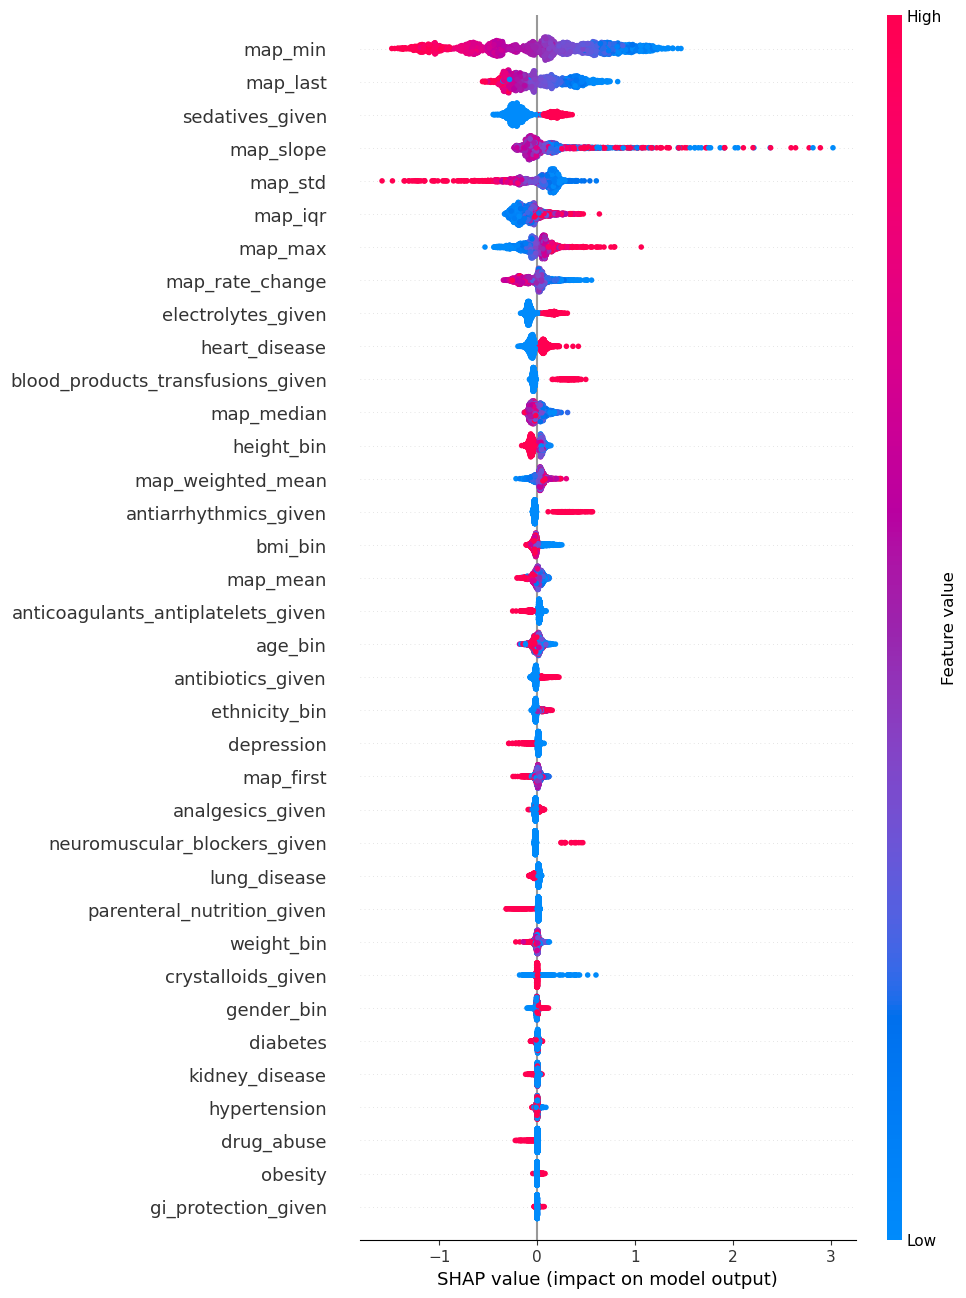

In [15]:
# --- Load model ---



booster = xgb.Booster()
booster.load_model(inv_model)

# --- load data ---

x_train, y_train, x_val, y_val,x_text,y_test = load_and_prepare_data_xgb('merged_noninv_features')

# --- tree explainer part ---
# sampling from X-train but ensuring we have enough positives in there
pos = x_train[y_train == 1].sample(n=500, random_state=42)
neg = x_train[y_train == 0].sample(n=1500, random_state=42)
x_sample = pd.concat([pos, neg]).sample(frac=1, random_state=42)  # shuffle

# replaces the entire precompute function for your use case
dtrain = xgb.DMatrix(x_sample, feature_names=x_sample.columns.tolist())
contribs = booster.predict(dtrain, pred_contribs=True)

explanation = shap.Explanation(
    values=contribs[:, :-1],
    base_values=contribs[:, -1],
    data=x_sample.values,
    feature_names=x_sample.columns.tolist()
)

# modify feature names

new_names = {
    "mean": "map_mean",
    "min": "map_min",
    "max": "map_max",
    "median": "map_median",
    "iqr": "map_iqr",
    "std": "map_std",
    "slope": "map_slope",
    "weighted_mean": "map_weighted_mean",
    "first": "map_first",
    "last": "map_last",
    "rate_change": "map_rate_change",
}

explanation.feature_names = [
    new_names.get(f, f) for f in explanation.feature_names
]

shap.plots.beeswarm(explanation, max_display=40)

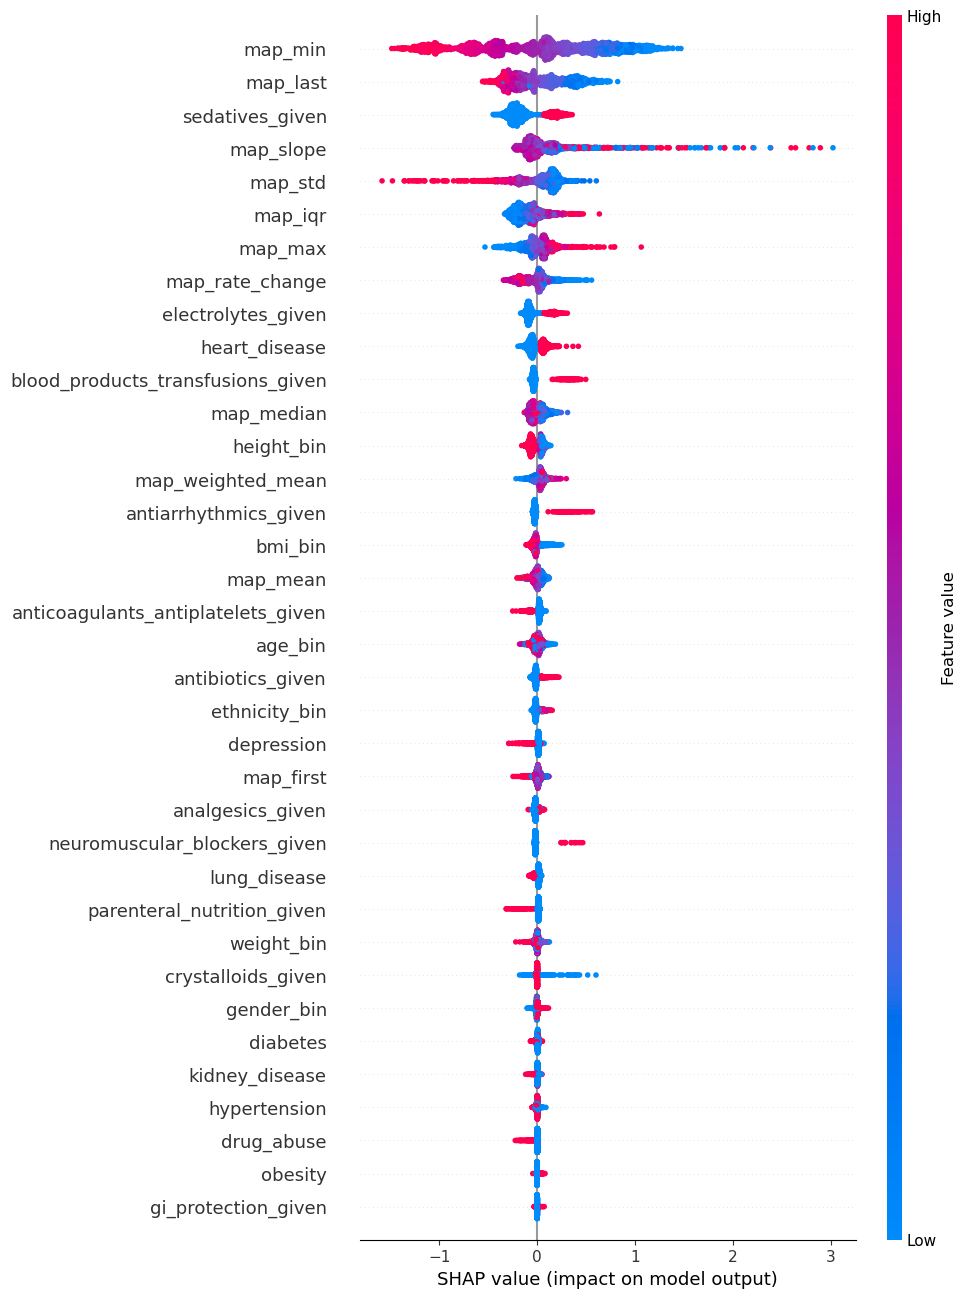

In [16]:
shap.plots.beeswarm(explanation, max_display=40)
plt.figure(figsize=(10, 8))

shap.plots.beeswarm(explanation, max_display=40, show=False)

plt.savefig("beeswarm_non_inv_all.png", dpi=300, bbox_inches="tight")
plt.close()

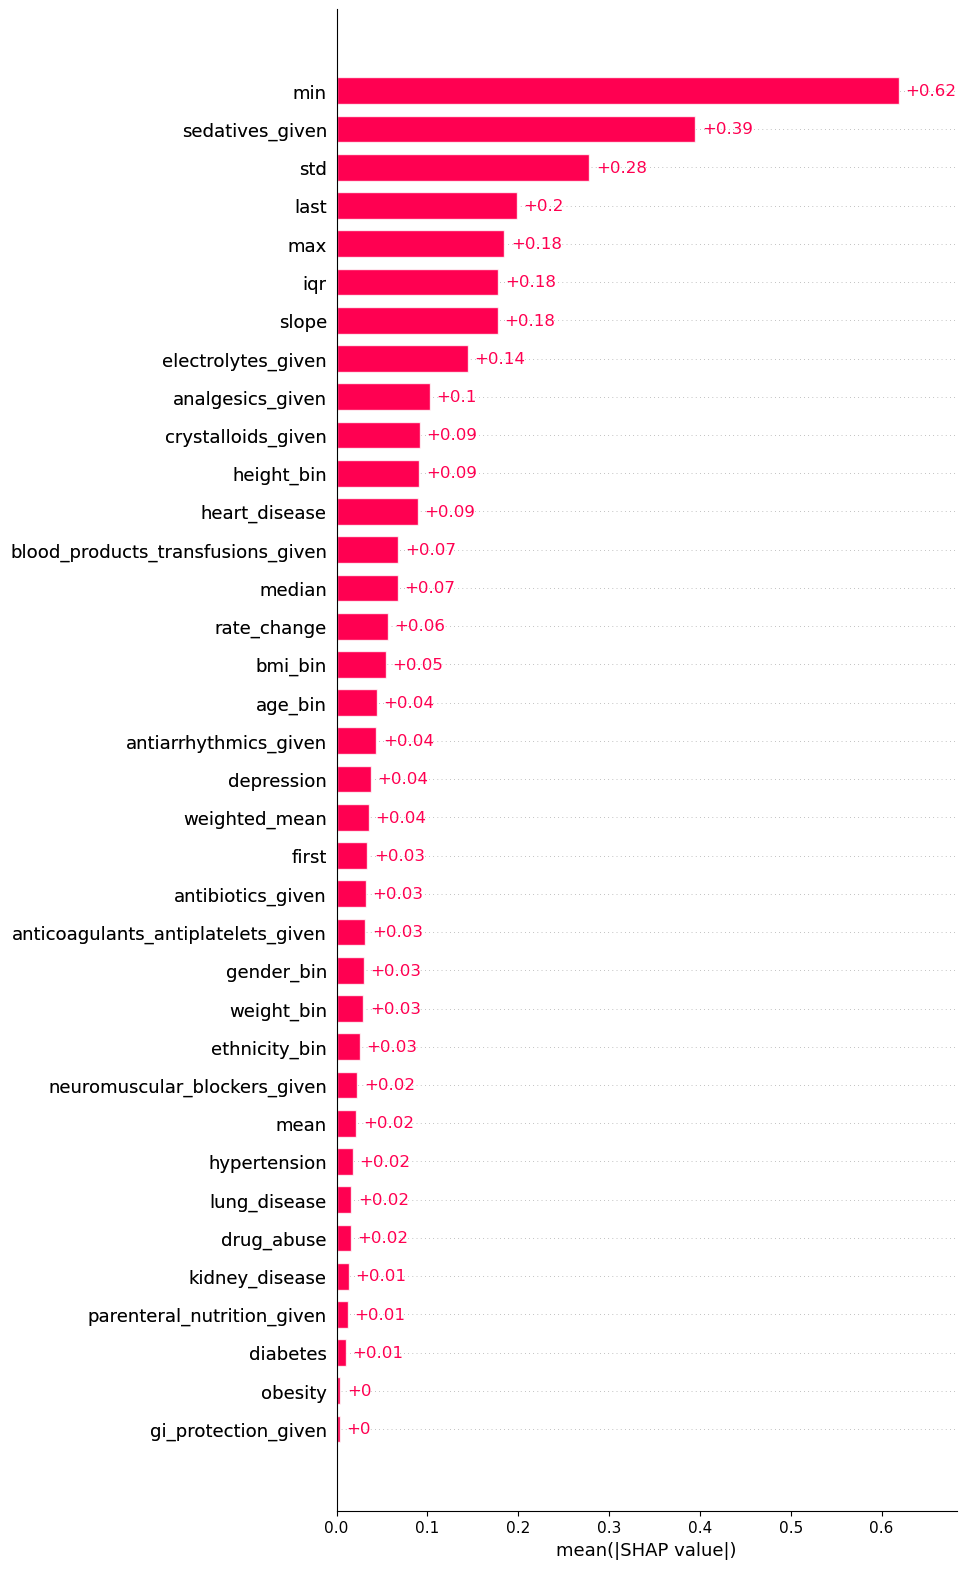

In [14]:
shap.plots.bar(explanation, max_display=40)

In [29]:

mean_abs = np.abs(explanation.values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": x_train.columns,
    "mean_abs_shap": mean_abs
}).sort_values("mean_abs_shap", ascending=False)

shap_df["relative_importance"] = shap_df["mean_abs_shap"] / shap_df["mean_abs_shap"].sum() * 100
shap_df["cumulative"] = shap_df["relative_importance"].cumsum()

print(shap_df.head(20))

                              feature  mean_abs_shap  relative_importance  \
2                                 min       0.619115            18.897745   
25                    sedatives_given       0.394854            12.052463   
4                                 std       0.278391             8.497559   
7                                last       0.198722             6.065748   
3                                 max       0.184726             5.638537   
5                                 iqr       0.177865             5.429110   
9                               slope       0.177360             5.413699   
32                 electrolytes_given       0.144162             4.400377   
30                   analgesics_given       0.102619             3.132322   
31                 crystalloids_given       0.091302             2.786884   
14                         height_bin       0.091181             2.783186   
22                      heart_disease       0.089754             2.739649   

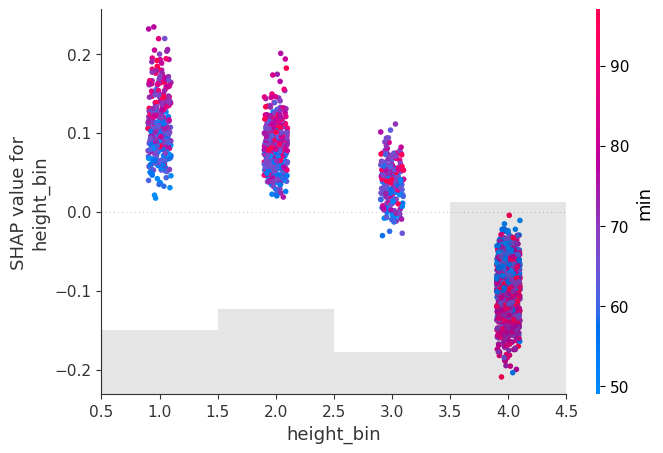

In [37]:
# height_bin -> bias? 

shap.plots.scatter(explanation[:, "height_bin"], color=explanation[:, "min"])

In [43]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shap

# Plot 1
shap.plots.scatter(explanation[:, "max"], color=explanation[:, "std"], show=False)
plt.savefig("tmp_max_std.png", dpi=300, bbox_inches="tight")
plt.close()

# Plot 2
shap.plots.scatter(explanation[:, "std"], color=explanation[:, "max"], show=False)
plt.savefig("tmp_std_max.png", dpi=300, bbox_inches="tight")
plt.close()

# Combine
img1 = mpimg.imread("tmp_max_std.png")
img2 = mpimg.imread("tmp_std_max.png")

fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes[0].imshow(img1)
axes[0].axis("off")
axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("shap_level_variability_interaction.png", dpi=300, bbox_inches="tight")
plt.close()


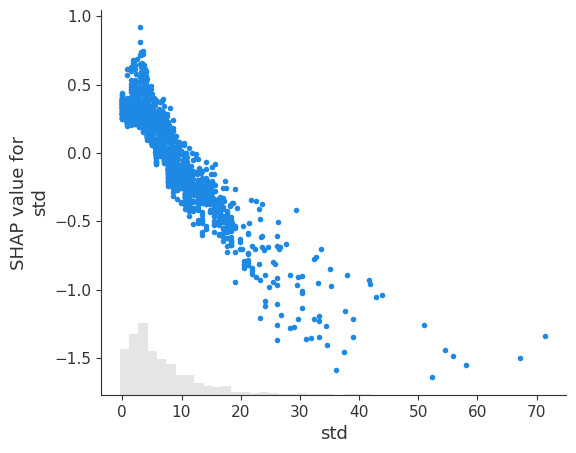

In [21]:
shap.plots.scatter(explanation[:, "std"]) 

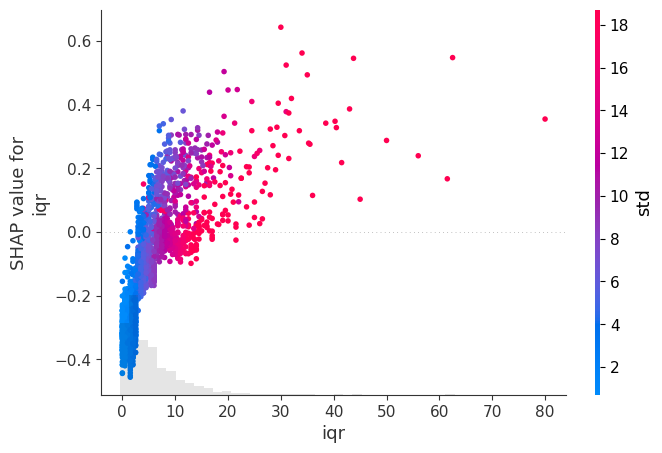

In [44]:
shap.plots.scatter(explanation[:, "iqr"], color=explanation)   # level feature

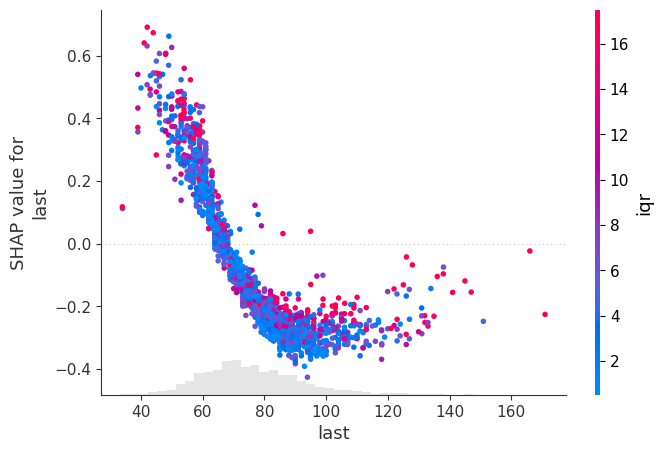

In [18]:
shap.plots.scatter(explanation[:, "last"], color=explanation)   # level feature

<Axes: >

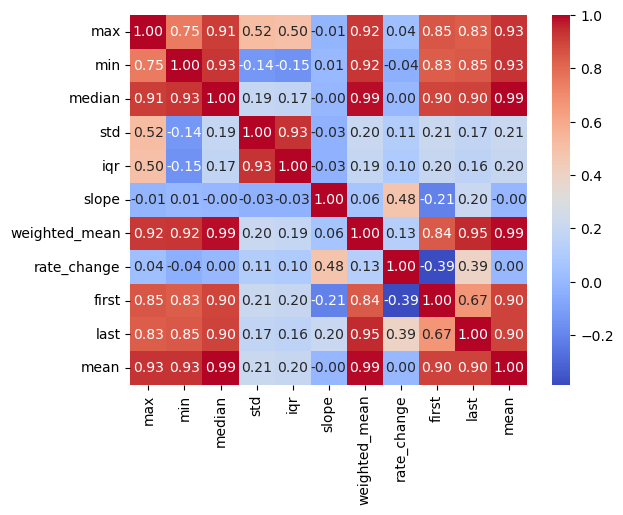

In [ ]:
# gegeben dass 82% der context windows nur 2 messungen beinhalten gibt es eigentlich nur 4 unabhängige Informationen
# std = iqr
# median = mean


import seaborn as sns
corr = x_train[[
    "max","min","median","std",
    "iqr","slope","weighted_mean",
    "rate_change","first","last","mean"
]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

<Axes: >

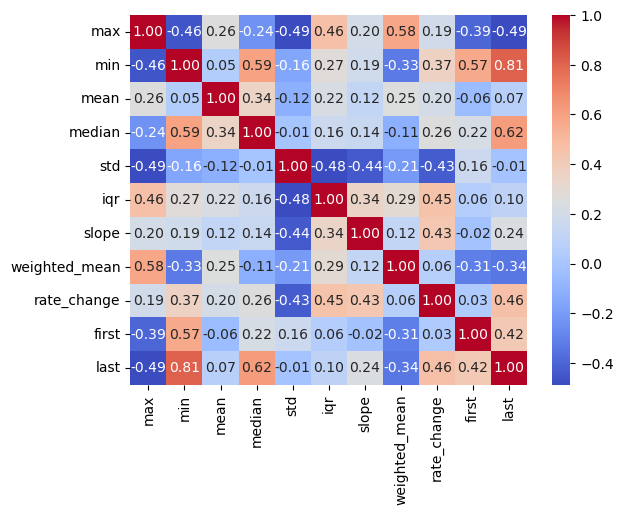

In [24]:
# SHAP korrelationsmatrix


map_feats = ["max","min", "mean","median","std",
             "iqr","slope","weighted_mean",
             "rate_change","first","last"]

feat_idx = [x_train.columns.tolist().index(f) for f in map_feats]
shap_map = explanation.values[:, feat_idx]

shap_corr = pd.DataFrame(shap_map, columns=map_feats).corr()
sns.heatmap(shap_corr, annot=True, fmt=".2f", cmap="coolwarm")

In [31]:
# SHAP in x_test
#x_train, y_train, x_val, y_val,x_test,y_test = load_and_prepare_data_xgb('merged_mix_features')
# --- tree explainer part ---
# sampling from X-train but ensuring we have enough positives in there
pos = x_text[y_test == 1].sample(n=500, random_state=42)
neg = x_text[y_test == 0].sample(n=1500, random_state=42)
x_sample = pd.concat([pos, neg]).sample(frac=1, random_state=42)  # shuffle

# replaces the entire precompute function for your use case
dtest = xgb.DMatrix(x_sample, feature_names=x_sample.columns.tolist())
contribs = booster.predict(dtest, pred_contribs=True)

explanation_test = shap.Explanation(
    values=contribs[:, :-1],
    base_values=contribs[:, -1],
    data=x_sample.values,
    feature_names=x_sample.columns.tolist()
)

<Axes: >

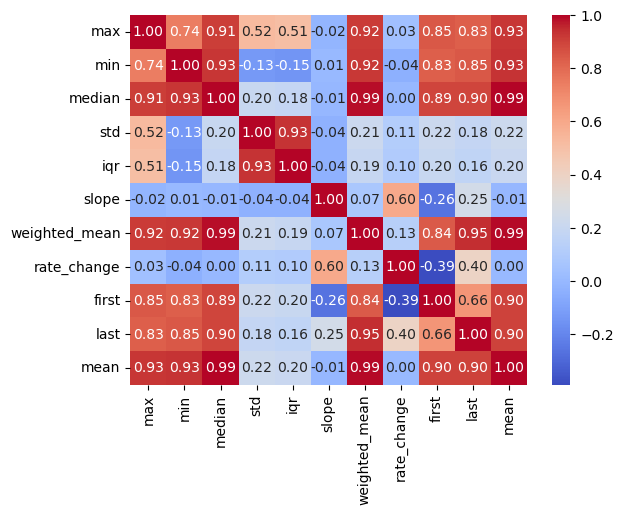

In [32]:
# gegeben dass 82% der context windows nur 2 messungen beinhalten gibt es eigentlich nur 4 unabhängige Informationen
# std = iqr
# median = mean
# ...

import seaborn as sns
corr = x_text[[
    "max","min","median","std",
    "iqr","slope","weighted_mean",
    "rate_change","first","last","mean"
]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

<Axes: >

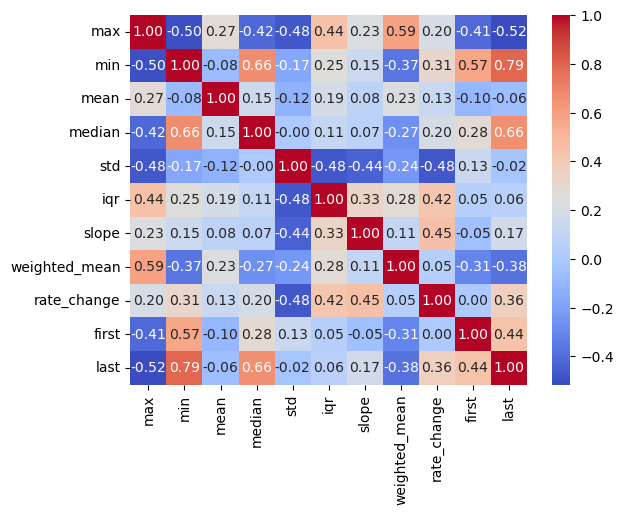

In [33]:
map_feats = ["max","min", "mean","median","std",
             "iqr","slope","weighted_mean",
             "rate_change","first","last"]

feat_idx = [x_text.columns.tolist().index(f) for f in map_feats]
shap_map = explanation_test.values[:, feat_idx]

shap_corr = pd.DataFrame(shap_map, columns=map_feats).corr()
sns.heatmap(shap_corr, annot=True, fmt=".2f", cmap="coolwarm")